# Using MikFoil simulation module

Although MikFoil functions as a meshing tool that is only part of it. The library was created to automate the process of airfoil simulation beginning from meshing - which we have already talked about in Tutorials 1 and 2, but also running CFD simulations with the help of [SU2](https://su2code.github.io/) and their postprocessing into necessary plots, data and contours. Furthermore the library validates the results with experimental data and is created in a way to allow for easy batch runs of many cases (More about this in later tutorials)

This tutorial explains all those features and steps. You will also learn about how MikFoil is  structured, which will make it much easier to perform batch analyses.

In [1]:
from pathlib import Path
from IPython.display import Image, display

from mikfoil.case import Case, MeshConfig
from mikfoil.main import execute_case


#Let's define a MeshConfig as before but this time with slightly finer mesh so we get more accurate results
mesh_config = MeshConfig(
    fineness=1.5, #Fineness = 1 is a default value but for most use cases it's recommended to use a higher finness
)


#Here we define another important object  - Case
case = Case(
    airfoil="NACA23012",
    aoa=8.0,
    mach=0.15,
    reynolds=3e6,
    mesh_config=mesh_config, #Notice that we pass MeshConfig inside Case 
    su2_config="default",
    project_dir="Tutorial_Cases/Tutorial_03"
)


Before anything we need to understand what exactly is `Case` in MikFoil. So in short it is a dataclass that holds information about all that is needed to define the simulation as well as some of the state and result variables. 

**To define a case it is required to provide:**

- Airfoil of which a CFD analysis will be performed.
- Reynolds number
- Mach number 
- Angle of attack

**Furthermore:**
- su2_config - defines a simulation setup that is run (`default`, `incompressible`, `multigrid`, `transition` and `wall_functions`), custom configs also can be defined (more about that in later Tutorials)
- xfoil_config - similar to su2_config, this parameter allows you to select the XFOIL template used for the validation run (like default), or provide a path to your own template.
- mesh_config - works the same as when you use MikFoil just as an mesher, with just one difference...
- target_y_plus - this is the only difference, as this variable overwrites `first_layer_height`
- project_dir - it defines the folder in which this case lives. That is where all generated meshes, SU2 configuration files, and simulation outputs are generated.
- experimental_data_file: an optional path to a CSV file containing experimental data for validation.



In [2]:
#So knowing more or less what Case is, let's just run it
execute_case(case)


We just ran the `case` which
- created a mesh
- ran the simulation
- validated the results with Xfoil
- Performed postprocessing and generated the plots

Note that this typically takes a few minutes, but for the purpose of this tutorial, we rely on the fact that MikFoil can detect if a Case has already run and will load the existing results instead of re-running the simulation.

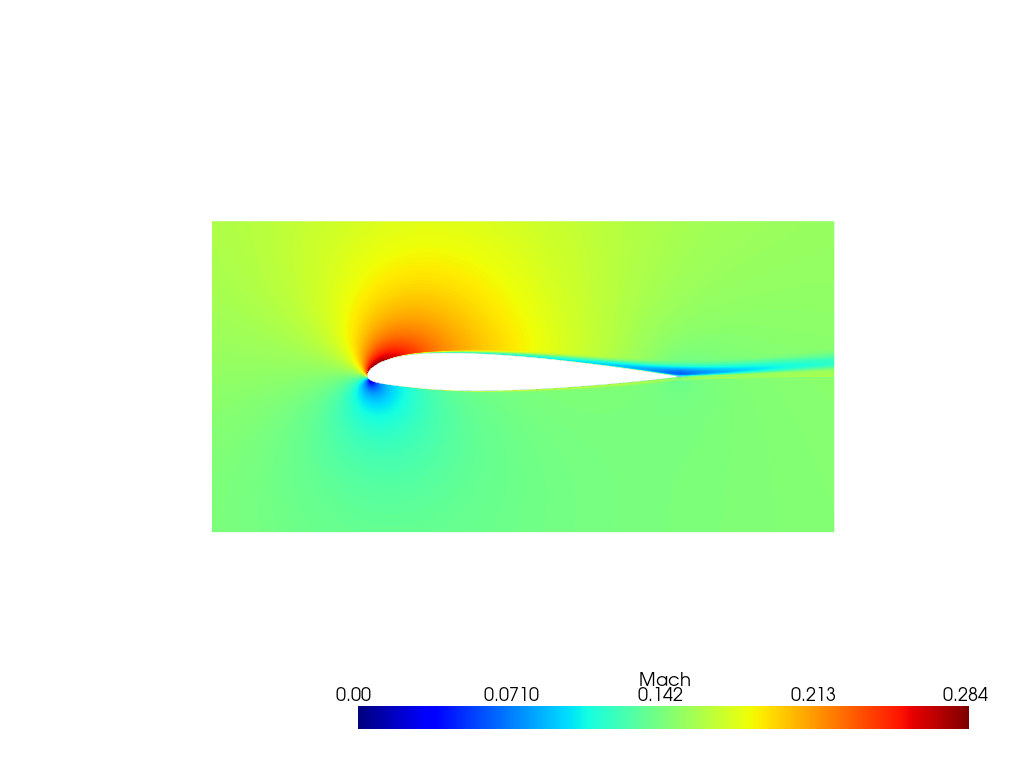

In [3]:
from IPython.display import Image, display

# Display the generated Mach contour
mach_contour_path = case.contours_dir / 'contour_mach.png'
display(Image(filename=mach_contour_path))


Here you can see a [Mach contour](./Tutorial_Cases/Tutorial_03/NACA23012_AoA_8_M_0.15_Re_3e06/contours/) 

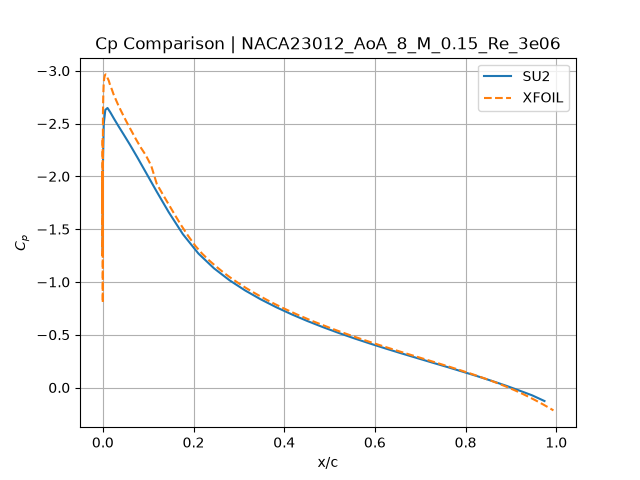

In [4]:
# Display the Cp validation plot comparing SU2 with XFOIL
cp_validation_path = case.validation_dir / 'cp_validation.png'
display(Image(filename=cp_validation_path))

By default every CFD case that is run is compared with XFOIL so you can get a general idea about the accuracy of the simulation easily.

In [5]:
import yaml

# The case_data.yaml file stores key parameters and computed forces
case_data_path = case.dir / "case_data.yaml"
with open(case_data_path, "r") as f:
    print(f.read())

success: true
xfoil_converged: true
execution_time: 292.4687805175781
cl: 0.9862200204
cd: 0.02154882203
cm: 0.007824650467
xfoil_cl: 1.0427
xfoil_cd: 0.00857
xfoil_cm: -0.0074
mesh_number_of_cells: 48694
mesh_min_angle: 51.42602009791865
mesh_max_skewness: 0.6163577608265192



For every case most important results that can be defined by single numbers are saved in [`case_data.yaml`](./Tutorial_Cases/Tutorial_03/NACA23012_AoA_8_M_0.15_Re_3e06/case_data.yaml) files